# 05 — Experimentos com instâncias Large

Objetivo: executar o PBIL-Fuzzy nas instâncias Large, registrar Cmax, tempo, evolução de alpha/beta e diversidade estrutural, e gerar uma tabela consolidada para análise posterior.

In [1]:
import os
import sys
import time
import copy
import json

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

caminho_raiz = os.path.abspath(os.path.join(os.getcwd(), ".."))
if caminho_raiz not in sys.path:
    sys.path.insert(0, caminho_raiz)

In [2]:
from src.core.instance import carregar_instancia, listar_instancias
from src.engine.pbil_fuzzy import PBILFuzzy
from src.utils import visualization

In [3]:
def carregar_configuracao(caminho_config):
    with open(caminho_config, "r", encoding="utf-8") as arquivo:
        return yaml.safe_load(arquivo)


def preparar_config_large(config_original, max_geracoes=None, n_pop=None):
    config_execucao = copy.deepcopy(config_original)

    if max_geracoes is not None:
        config_execucao["criterio_parada"]["max_geracoes"] = max_geracoes

    if n_pop is not None:
        config_execucao["pbil"]["n_pop"] = n_pop

    return config_execucao


def calcular_semente_execucao(semente_base, indice_instancia, indice_execucao):
    return int(semente_base + 1000 * indice_instancia + indice_execucao)


def executar_rodada_large(caminho_instancia, config_execucao, indice_instancia, indice_execucao):
    instancia = carregar_instancia(caminho_instancia)

    semente = calcular_semente_execucao(
        config_execucao["execucao"]["seed"],
        indice_instancia,
        indice_execucao,
    )
    gerador_aleatorio = np.random.default_rng(semente)

    motor = PBILFuzzy(
        instancia=instancia,
        config=config_execucao,
        gerador_aleatorio=gerador_aleatorio,
    )

    tempo_inicio = time.time()
    resultado = motor.executar()
    tempo_segundos = time.time() - tempo_inicio

    return {
        "instancia": instancia.nome,
        "numero_jobs": instancia.numero_jobs,
        "numero_maquinas": instancia.numero_maquinas,
        "indice_execucao": indice_execucao,
        "semente": semente,
        "cmax_best": float(resultado.cmax_best),
        "geracoes": len(resultado.historico_cmax_best),
        "tempo_segundos": round(float(tempo_segundos), 3),
        "alpha_medio": float(np.mean(resultado.historico_alpha)),
        "beta_medio": float(np.mean(resultado.historico_beta)),
        "diversidade_media": float(np.mean(resultado.historico_diversidade_estrutural)),
        "historico_cmax_best": resultado.historico_cmax_best,
        "historico_alpha": resultado.historico_alpha,
        "historico_beta": resultado.historico_beta,
        "historico_diversidade_estrutural": resultado.historico_diversidade_estrutural,
    }

In [4]:
caminho_config = os.path.join(caminho_raiz, "config.yaml")
config = carregar_configuracao(caminho_config)

diretorio_large = os.path.join(caminho_raiz, config["instancia"]["diretorio_large"])
caminhos_instancias_large = listar_instancias(diretorio_large)

print(f"Instâncias Large encontradas: {len(caminhos_instancias_large)}")
print("Primeiras instâncias:")
for caminho in caminhos_instancias_large[:10]:
    print(" -", os.path.basename(caminho))

Instâncias Large encontradas: 720
Primeiras instâncias:
 - Ta001_2.txt
 - Ta001_3.txt
 - Ta001_4.txt
 - Ta001_5.txt
 - Ta001_6.txt
 - Ta001_7.txt
 - Ta002_2.txt
 - Ta002_3.txt
 - Ta002_4.txt
 - Ta002_5.txt


In [5]:
max_instancias_large = 10
n_execucoes_por_instancia = 3
max_geracoes_large = 100
n_pop_large = 40

config_large = preparar_config_large(
    config,
    max_geracoes=max_geracoes_large,
    n_pop=n_pop_large,
)

caminhos_selecionados_large = caminhos_instancias_large[:max_instancias_large]

print(f"Instâncias selecionadas: {len(caminhos_selecionados_large)}")
print(f"Execuções por instância: {n_execucoes_por_instancia}")
print(f"Gerações por execução: {config_large['criterio_parada']['max_geracoes']}")
print(f"Tamanho da população: {config_large['pbil']['n_pop']}")

Instâncias selecionadas: 10
Execuções por instância: 3
Gerações por execução: 100
Tamanho da população: 40


In [6]:
linhas_resultados_large = []

for indice_instancia, caminho_instancia in enumerate(caminhos_selecionados_large):
    nome_instancia = os.path.splitext(os.path.basename(caminho_instancia))[0]

    for indice_execucao in range(n_execucoes_por_instancia):
        linha_resultado = executar_rodada_large(
            caminho_instancia=caminho_instancia,
            config_execucao=config_large,
            indice_instancia=indice_instancia,
            indice_execucao=indice_execucao,
        )

        linhas_resultados_large.append(linha_resultado)

        print(
            f"{nome_instancia} | execução {indice_execucao + 1}/{n_execucoes_por_instancia} "
            f"| Cmax_best={linha_resultado['cmax_best']:.2f} "
            f"| tempo={linha_resultado['tempo_segundos']:.2f}s"
        )

tabela_resultados_large = pd.DataFrame(linhas_resultados_large)
tabela_resultados_large.head()

Ta001_2 | execução 1/3 | Cmax_best=3021.00 | tempo=59.53s
Ta001_2 | execução 2/3 | Cmax_best=2927.00 | tempo=103.57s
Ta001_2 | execução 3/3 | Cmax_best=2876.00 | tempo=68.08s
Ta001_3 | execução 1/3 | Cmax_best=2668.00 | tempo=111.53s
Ta001_3 | execução 2/3 | Cmax_best=3091.00 | tempo=60.19s
Ta001_3 | execução 3/3 | Cmax_best=2769.00 | tempo=31.66s
Ta001_4 | execução 1/3 | Cmax_best=2801.00 | tempo=58.62s
Ta001_4 | execução 2/3 | Cmax_best=2917.00 | tempo=60.49s
Ta001_4 | execução 3/3 | Cmax_best=2852.00 | tempo=114.56s
Ta001_5 | execução 1/3 | Cmax_best=2886.00 | tempo=98.28s
Ta001_5 | execução 2/3 | Cmax_best=2781.00 | tempo=66.96s
Ta001_5 | execução 3/3 | Cmax_best=2944.00 | tempo=86.44s
Ta001_6 | execução 1/3 | Cmax_best=2810.00 | tempo=99.94s
Ta001_6 | execução 2/3 | Cmax_best=2778.00 | tempo=98.33s
Ta001_6 | execução 3/3 | Cmax_best=2880.00 | tempo=86.09s
Ta001_7 | execução 1/3 | Cmax_best=2777.00 | tempo=77.25s
Ta001_7 | execução 2/3 | Cmax_best=2906.00 | tempo=60.74s
Ta001_7 | e

,instancia,numero_jobs,numero_maquinas,indice_execucao,semente,cmax_best,geracoes,tempo_segundos,alpha_medio,beta_medio,diversidade_media,historico_cmax_best,historico_alpha,historico_beta,historico_diversidade_estrutural
0,Ta001_2,20,5,0,42,3021.0,100,59.526,0.517865,0.4995,0.487921,"[3809.0, 3809.0, 3657.0, 3657.0, 3657.0, 3597....","[0.4995000000000038, 0.49950000000000755, 0.49...","[0.4995000000000038, 0.49950000000000755, 0.49...","[0.49871929824561406, 0.49902960526315787, 0.4..."
1,Ta001_2,20,5,1,43,2927.0,100,103.574,0.507649,0.4995,0.494774,"[3784.0, 3728.0, 3728.0, 3671.0, 3671.0, 3671....","[0.4995000000000057, 0.49950000000000816, 0.49...","[0.4995000000000057, 0.49950000000000816, 0.49...","[0.49780701754385975, 0.4974003189792664, 0.50..."
2,Ta001_2,20,5,2,44,2876.0,100,68.078,0.529350,0.4995,0.494872,"[3505.0, 3505.0, 3505.0, 3505.0, 3492.0, 3450....","[0.5062889273966081, 0.5047619876014001, 0.500...","[0.49950000000000566, 0.4994999999999976, 0.49...","[0.5009398496240601, 0.4965170278637771, 0.506..."
3,Ta001_3,20,5,0,1042,2668.0,100,111.535,0.522450,0.4995,0.491520,"[3900.0, 3536.0, 3536.0, 3536.0, 3536.0, 3536....","[0.4995000000000026, 0.5047658839843725, 0.512...","[0.4995000000000026, 0.49949999999999695, 0.49...","[0.501475279106858, 0.4976842105263158, 0.4999..."
4,Ta001_3,20,5,1,1043,3091.0,100,60.191,0.515688,0.4995,0.491666,"[3621.0, 3621.0, 3621.0, 3621.0, 3621.0, 3537....","[0.49954168623993406, 0.5005349094786415, 0.49...","[0.49950000000000533, 0.49950000000000605, 0.4...","[0.4964819944598339, 0.508343653250774, 0.5024..."


In [7]:
colunas_resumo = [
    "instancia",
    "numero_jobs",
    "numero_maquinas",
    "indice_execucao",
    "semente",
    "cmax_best",
    "geracoes",
    "tempo_segundos",
    "alpha_medio",
    "beta_medio",
    "diversidade_media",
]

tabela_resumo_large = tabela_resultados_large[colunas_resumo].copy()
tabela_resumo_large

,instancia,numero_jobs,numero_maquinas,indice_execucao,semente,cmax_best,geracoes,tempo_segundos,alpha_medio,beta_medio,diversidade_media
0,Ta001_2,20,5,0,42,3021.0,100,59.526,0.517865,0.4995,0.487921
1,Ta001_2,20,5,1,43,2927.0,100,103.574,0.507649,0.4995,0.494774
2,Ta001_2,20,5,2,44,2876.0,100,68.078,0.529350,0.4995,0.494872
3,Ta001_3,20,5,0,1042,2668.0,100,111.535,0.522450,0.4995,0.491520
4,Ta001_3,20,5,1,1043,3091.0,100,60.191,0.515688,0.4995,0.491666
5,Ta001_3,20,5,2,1044,2769.0,100,31.657,0.534848,0.4995,0.488736
6,Ta001_4,20,5,0,2042,2801.0,100,58.618,0.511548,0.4995,0.490830
7,Ta001_4,20,5,1,2043,2917.0,100,60.487,0.525174,0.4995,0.488936
8,Ta001_4,20,5,2,2044,2852.0,100,114.557,0.516950,0.4995,0.491858
9,Ta001_5,20,5,0,3042,2886.0,100,98.280,0.511819,0.4995,0.491245


In [8]:
tabela_agregada_large = (
    tabela_resumo_large
    .groupby(["instancia", "numero_jobs", "numero_maquinas"], as_index=False)
    .agg(
        cmax_medio=("cmax_best", "mean"),
        cmax_desvio_padrao=("cmax_best", "std"),
        cmax_melhor=("cmax_best", "min"),
        cmax_pior=("cmax_best", "max"),
        tempo_medio_segundos=("tempo_segundos", "mean"),
        alpha_medio=("alpha_medio", "mean"),
        beta_medio=("beta_medio", "mean"),
        diversidade_media=("diversidade_media", "mean"),
    )
    .sort_values(["numero_jobs", "numero_maquinas", "instancia"])
)

tabela_agregada_large

,instancia,numero_jobs,numero_maquinas,cmax_medio,cmax_desvio_padrao,cmax_melhor,cmax_pior,tempo_medio_segundos,alpha_medio,beta_medio,diversidade_media
0,Ta001_2,20,5,2941.333333,73.554968,2876.0,3021.0,77.059333,0.518288,0.4995,0.492522
1,Ta001_3,20,5,2842.666667,220.912502,2668.0,3091.0,67.794333,0.524329,0.4995,0.490641
2,Ta001_4,20,5,2856.666667,58.140634,2801.0,2917.0,77.887333,0.517891,0.4995,0.490541
3,Ta001_5,20,5,2870.333333,82.621628,2781.0,2944.0,83.893667,0.515060,0.4995,0.490601
4,Ta001_6,20,5,2822.666667,52.166400,2778.0,2880.0,94.784000,0.519248,0.4995,0.491665
5,Ta001_7,20,5,2841.666667,64.500646,2777.0,2906.0,79.005000,0.517624,0.4995,0.484478
6,Ta002_2,20,5,2907.000000,269.170949,2684.0,3206.0,77.458667,0.515606,0.4995,0.486822
7,Ta002_3,20,5,2995.333333,104.356760,2914.0,3113.0,73.141667,0.515919,0.4995,0.494988
8,Ta002_4,20,5,3029.000000,180.435584,2828.0,3177.0,81.085667,0.513235,0.4995,0.482353
9,Ta002_5,20,5,2982.333333,195.359498,2825.0,3201.0,67.153000,0.518130,0.4995,0.487350


In [9]:
melhor_linha = tabela_resultados_large.loc[tabela_resultados_large["cmax_best"].idxmin()]
print("Melhor execução Large")
print(f"Instância: {melhor_linha['instancia']}")
print(f"Execução: {melhor_linha['indice_execucao']}")
print(f"Cmax_best: {melhor_linha['cmax_best']:.2f}")
print(f"Tempo: {melhor_linha['tempo_segundos']:.2f}s")

Melhor execução Large
Instância: Ta001_3
Execução: 0
Cmax_best: 2668.00
Tempo: 111.53s


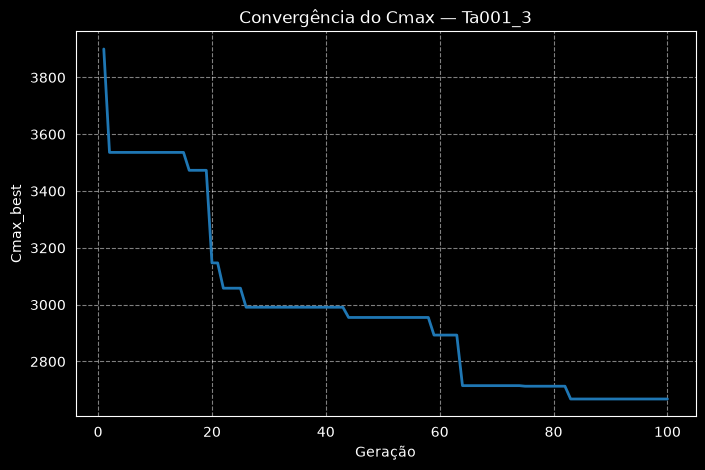

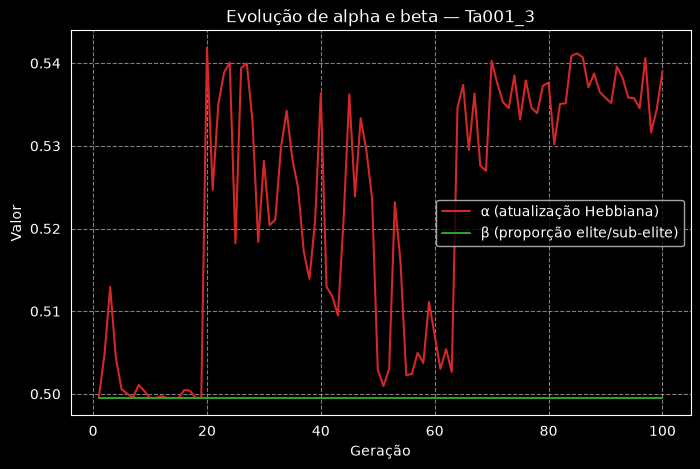

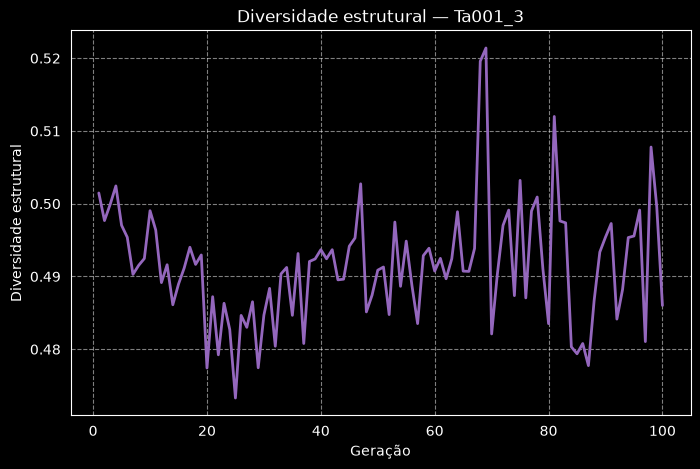

In [10]:
visualization.plotar_convergencia_cmax(
    melhor_linha["historico_cmax_best"],
    titulo=f"Convergência do Cmax — {melhor_linha['instancia']}",
)

visualization.plotar_evolucao_alpha_beta(
    melhor_linha["historico_alpha"],
    melhor_linha["historico_beta"],
    titulo=f"Evolução de alpha e beta — {melhor_linha['instancia']}",
)

visualization.plotar_diversidade_estrutural(
    melhor_linha["historico_diversidade_estrutural"],
    titulo=f"Diversidade estrutural — {melhor_linha['instancia']}",
)

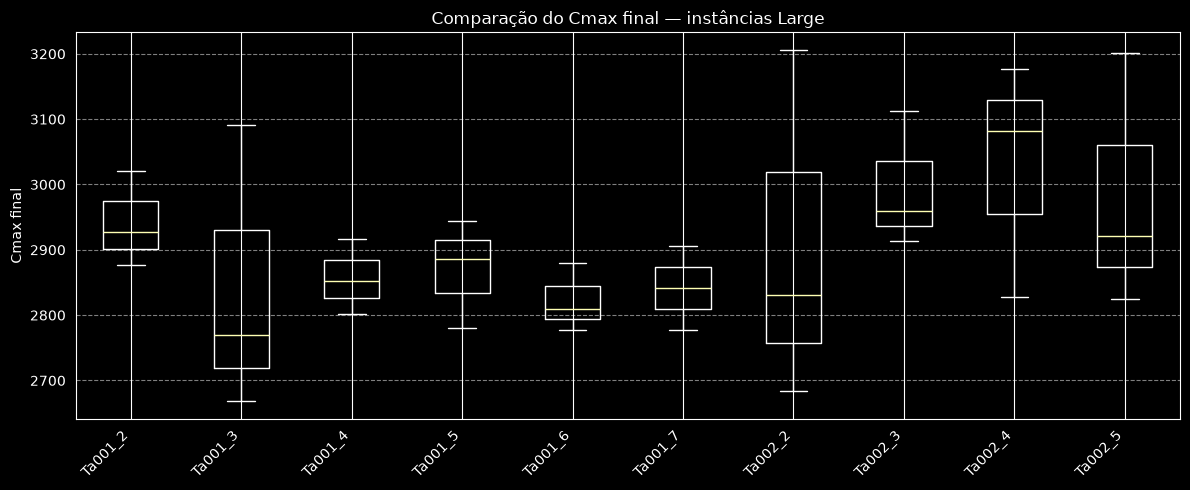

In [11]:
resultados_por_instancia = {
    nome_instancia: grupo["cmax_best"].tolist()
    for nome_instancia, grupo in tabela_resumo_large.groupby("instancia")
}

visualization.plotar_comparacao_boxplot(
    resultados_por_instancia,
    titulo="Comparação do Cmax final — instâncias Large",
)

In [12]:
diretorio_outputs = os.path.join(caminho_raiz, config["caminhos"]["outputs"])
os.makedirs(diretorio_outputs, exist_ok=True)

caminho_csv_large = os.path.join(diretorio_outputs, "resumo_large.csv")
caminho_json_large = os.path.join(diretorio_outputs, "resumo_large_com_historicos.json")

tabela_resumo_large.to_csv(caminho_csv_large, index=False, encoding="utf-8")

with open(caminho_json_large, "w", encoding="utf-8") as arquivo:
    json.dump(linhas_resultados_large, arquivo, indent=2, ensure_ascii=False)

print(f"Resumo salvo em: {caminho_csv_large}")
print(f"Históricos salvos em: {caminho_json_large}")

Resumo salvo em: /mnt/c/Users/Renef/Documents/trab_sint/data/results/outputs/resumo_large.csv
Históricos salvos em: /mnt/c/Users/Renef/Documents/trab_sint/data/results/outputs/resumo_large_com_historicos.json
